# torch 환경 확인

In [1]:
import torch
print('PyTorch', torch.__version__)
print('CUDA 사용 가능:', torch.cuda.is_available())
print('GPU:', torch.cuda.get_device_name(0))

PyTorch 2.6.0+cu124
CUDA 사용 가능: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [ ]:
# !pip install -U scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -------------------------------- ------- 6.6/8.1 MB 36.6 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 33.4 MB/s  0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2

# iris 신경망 v.pt

In [2]:
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

In [3]:
# 1. 재현성 고정
torch.manual_seed(1)

# 2. 데이터 로드
iris = load_iris()
X =iris.data
y =iris.target
X.shape, y.shape

((150, 4), (150,))

In [4]:
# 3. train/test 분할
X_train, X_test, y_train, y_test = train_test_split(
  X,y, test_size=0.3, random_state=1,stratify=y
)

In [6]:
# 4. 스케일링 (X값, not y) - array, 사이킷런 라이브러리
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# 5. Tensor 변환 (ndarray -> torch.tensor)
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [9]:
# 6. Dataset / DataLoader 
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=16,shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [21]:
# 7. 신경망 모델 정의
class IrisNet(nn.Module):
  def __init__(self): # 신경망모델 생성자
    super().__init__()
    self.fc1 = nn.Linear(4,16) # 입력특성 4개
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(16,3) # 출력클래스 3개
    
  def forward(self, x): # 순방향학습
      x= self.fc1(x)
      x= self.relu(x)
      x= self.fc2(x)
      return x

In [22]:
model = IrisNet()
model

IrisNet(
  (fc1): Linear(in_features=4, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=3, bias=True)
)

In [23]:
# 8. 손실함수와 옵티마이저
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [31]:
# 9. 학습루프
num_epochs = 150
loss_history = [] # < 이 줄 추가

for epoch in range(num_epochs):
  model.train() # 학습
  running_loss =0.0

  for x_batch, y_batch in train_loader: # 16batch
    optimizer.zero_grad() # 기울기 초기화
    outputs = model(x_batch) # 순전파
    loss= criterion(outputs, y_batch) # 손실 계산
    loss.backward() # 역전파
    optimizer.step() # 가중치 업데이트

    running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    loss_history.append(epoch_loss)

    if (epoch+1)% 10 ==0:
      print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}')

Epoch [10/150], Loss: 0.0014
Epoch [10/150], Loss: 0.0025
Epoch [10/150], Loss: 0.0117
Epoch [10/150], Loss: 0.0138
Epoch [10/150], Loss: 0.0160
Epoch [10/150], Loss: 0.0172
Epoch [10/150], Loss: 0.0189
Epoch [20/150], Loss: 0.0002
Epoch [20/150], Loss: 0.0008
Epoch [20/150], Loss: 0.0037
Epoch [20/150], Loss: 0.0130
Epoch [20/150], Loss: 0.0139
Epoch [20/150], Loss: 0.0152
Epoch [20/150], Loss: 0.0183
Epoch [30/150], Loss: 0.0000
Epoch [30/150], Loss: 0.0008
Epoch [30/150], Loss: 0.0008
Epoch [30/150], Loss: 0.0157
Epoch [30/150], Loss: 0.0197
Epoch [30/150], Loss: 0.0198
Epoch [30/150], Loss: 0.0251
Epoch [40/150], Loss: 0.0001
Epoch [40/150], Loss: 0.0001
Epoch [40/150], Loss: 0.0001
Epoch [40/150], Loss: 0.0086
Epoch [40/150], Loss: 0.0128
Epoch [40/150], Loss: 0.0140
Epoch [40/150], Loss: 0.0187
Epoch [50/150], Loss: 0.0003
Epoch [50/150], Loss: 0.0023
Epoch [50/150], Loss: 0.0023
Epoch [50/150], Loss: 0.0139
Epoch [50/150], Loss: 0.0156
Epoch [50/150], Loss: 0.0158
Epoch [50/150]

In [32]:
# 10. 평가
model.eval()
correct =0
total=0

with torch.no_grad():
  for x_batch, y_batch in test_loader:
    outputs = model(x_batch)
    _, predicted = torch.max(outputs,1)
    total += y_batch.size(0)
    correct += (predicted == y_batch).sum().item()

accuracy = 100*correct/total
print(f'Test Accuracy: {accuracy:.2f}%')

Test Accuracy: 95.56%


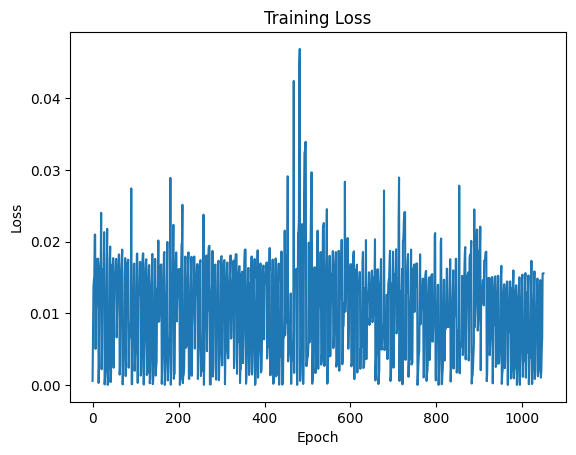

In [33]:
import matplotlib.pyplot as plt
plt.plot(loss_history)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [36]:
# 1. 환경 확인
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch: 2.6.0+cu124
CUDA available: True
Using device: cuda


In [37]:
# 2. 데이터셋 로드
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.05MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 149kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.62MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.29MB/s]


In [42]:
# 3. 모델 정의
import torch.nn as nn
import torch.nn.functional as F

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)  # Flatten
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

model = MLP().to(device)

In [39]:
# 4. 손실함수와 옵티마이저
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [40]:
# 5. 학습 루프
epochs = 3
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

Epoch 1/3, Loss: 0.3464
Epoch 2/3, Loss: 0.1574
Epoch 3/3, Loss: 0.1159


In [ ]:
# 6. 평가
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        outputs = model(X)
        _, preds = torch.max(outputs, 1)
        correct += (preds == y).sum().item()
        total += y.size(0)

print(f"Test Accuracy: {100 * correct / total:.2f}%")